This notebook was made using Python version 3.10.20.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as img
#import spectral
import numpy as np
import spectral.io.envi as envi
import os
from ipywidgets import interact
import cv2

### Info

Sensor type in the Kitchen dataset: SPECIM IQ

Serial number: 190-1000103

Sensor ID: XSB32570209

Firmware: 2019.05.31.1

Used spectral bands: between 397.32 nm and 1003.58 nm (from visible violet to near-infrared)

The folder structure of the imaging data is the following:

<pre>
[path]/everyday_objects/
                    |_kitchen/
                    | |_basmatiriisi/
                    |   |_capture/
                    |     |_[nr].hdr
                    |       [nr].raw
                    |       DARKREF_[nr].hrd
                    |       DARKREF_[nr].raw
                    |       WHITEDARKREF_[nr].hrd
                    |       WHITEDARKREF_[nr].raw
                    |       WHITEREF_[nr].hrd
                    |       WHITEREF_[nr].raw
                    |     metadata/
                    |     |_[nr].xml
                    |     results/
                    |     |_REFLECTANCE_[nr].dat
                    |       REFLECTANCE_[nr].hdr
                    |       REFLECTANCE_[nr].png
                    |       RGBBACKGROUND_[nr].png
                    |       RGBSCENE_[nr].png
                    |       RGBVIEWFINDER_[nr].png
                    |     .validated
                    |     [nr].png
                    |     manifest.xml
                    |  ...
                    |_kitchenday2/
</pre>

`[nr]` refers to the number associated with the specific capture. The number can be found, for example, in the name of the PNG file in the imaging folder.

This Python notebook has been made to demonstrate and aid the usage of hyperspectral (HS) images with Python. The HS material used in this notebook is the Kitchen dataset: it contains HS images, also called data cubes, of 23 light-colored substances found in a regular kitchen. The images have been captured with 204 spectral bands and have 512 $\times$ 512 px spatial resolution and 7 nm spectral resolution. The images also have ground truth annotations available. There are also 4 images with multiple different substances.

<br>

The images are called "data cubes", because the hyperspectral data has been combined to form a 3-dimensional object (x, y, $\lambda$). In this case, the images have 512 $\times$ 512 px spatial resolution, so the data cube is 512 pixels wide and 512 pixels tall (the x and y dimension). The different spectral bands form the third dimension ($\lambda$) of the cube, also called the "spectral dimension". Basically, in this case, the cube is 204 bands "deep".

<br>

Below is an example PNG image of a petridish filled with basmati rice on a black background.

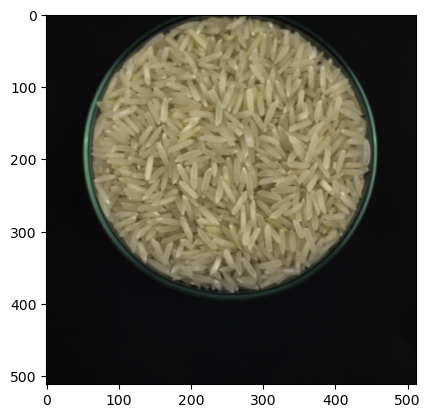

In [3]:
img = img.imread('/n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/040.png')
plt.imshow(img)

### Preprocessing

Necessary helper functions:

In [12]:
def get_file_paths(base_path):
    folders = sorted([
        f for f in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, f))])
    file_numbers = []
    for f in folders:
        for l in os.listdir(base_path+f+'/metadata/'):
            if l.endswith('.xml'):
                file_numbers.append(str(l.replace('.xml', '')))
    if int(len(folders)) != int(len(file_numbers)):
        print("Warning: couldn't find all file numbers; returning empty arrays.")
        return [], []
    return folders, file_numbers


# TODO: generalisoi
# Returns two arrays: first one with the folder path "kitchen[day2]/[object]" and the second with the corresponding file number.
def get_all_file_paths(path):
    folders1, nums1 = get_file_paths(path+'kitchen/')
    ind = [folders1.index('sekoite1'), folders1.index('sekoite2')]
    del folders1[ind[0]:ind[1]+1]
    del nums1[ind[0]:ind[1]+1]
    for i, folder in enumerate(folders1):
        folders1[i] = 'kitchen/'+folder+'/'
    folders2, nums2 = get_file_paths(path+'kitchenday2/')
    ind = [folders2.index('sekoitus3'), folders2.index('sekoitus4')]
    del folders2[ind[0]:ind[1]+1]
    del nums2[ind[0]:ind[1]+1]
    for i, folder in enumerate(folders2):
        folders2[i] = 'kitchenday2/'+folder+'/'
    return folders1 + folders2, nums1 + nums2


# Data on nyt kuutio.
# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def load_and_compute_reflectance(path, folder_name, file_number):
    folder_path = path + folder_name + '/capture/'
    paths = {
        'raw':   os.path.join(folder_path, f"{file_number}.hdr"),
        'white': os.path.join(folder_path, f"WHITEREF_{file_number}.hdr"),
        'dark':  os.path.join(folder_path, f"DARKREF_{file_number}.hdr"),
    }

    for key, p in paths.items():
        if not os.path.isfile(p):
            print(f"  Missing {key} file: {p}")
            return None, None

    raw, wavelengths = open_image(paths['raw'])
    white, _ = open_image(paths['white'])
    dark, _  = open_image(paths['dark'])

    if any(x is None for x in [raw, white, dark]):
        print("  Failed to load one or more image cubes.")
        return None, None
    
    denominator = white - dark
    denominator[denominator == 0] = 1e-6

    # np.clip: limits the values between given given values, here 0 and 1
    reflectance = np.clip((raw - dark) / denominator, 0, 1)
    return reflectance, wavelengths


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def open_image(file_path):
    try:
        image = envi.open(file_path)
        data = image.load()

        wavelengths = image.metadata.get('wavelength', None)
        if wavelengths:
            wavelengths = [float(w) for w in wavelengths]

        return data, wavelengths

    except Exception as e:
        print(f"  Error loading {file_path}: {e}")
        return None, None
    

# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def create_sample_mask(cube, band=None):
    if band is None:
        band = min_max_reflectance(cube)[2]

    img = cube[:, :, band]
    img_u8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    # Original:
    #_, mask = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    blur = cv2.GaussianBlur(img_u8,(5,5),0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return mask


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def segment_sample(cube, mask, margin=5, roi_mode="single", min_roi_area=50):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("  Warning: no contours found; returning original image.")
        return cube.copy(), mask.copy()

    # Sort by area (largest first)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    roi_mask = np.zeros_like(mask, dtype=np.uint8)

    if roi_mode == "single":
        # Keep the largest contour whose polygon approximation has >= 5 vertices
        for c in contours:
            if len(cv2.approxPolyDP(c, 3, True)) >= 5:
                cv2.fillPoly(roi_mask, [c], 255)
                break
        else:
            # Fallback: use the largest contour regardless
            cv2.fillPoly(roi_mask, [contours[0]], 255)

    elif roi_mode == "multiple":
        for c in contours:
            if cv2.contourArea(c) >= min_roi_area:
                cv2.fillPoly(roi_mask, [c], 255)
    else:
        raise ValueError(f"roi_mode must be 'single' or 'multiple', got '{roi_mode}'")

    # Apply mask (element-wise multiply is correct for float arrays)
    filtered = cube * (roi_mask[:, :, np.newaxis] / 255.0)

    # Crop to bounding box of the combined mask
    # Rajaa kuvan vain maskiin.
    coords = cv2.findNonZero(roi_mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        x = max(0, x - margin)
        y = max(0, y - margin)
        w = min(cube.shape[1] - x, w + 2 * margin)
        h = min(cube.shape[0] - y, h + 2 * margin)
        segmented = filtered[y:y+h, x:x+w]
        roi_mask  = roi_mask[y:y+h, x:x+w]
    else:
        segmented = filtered

    return segmented, roi_mask


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def extract_mean_spectrum(cube, mask):
    pixels = cube[mask > 0]
    if pixels.size == 0:
        print("  Warning: mask is empty; returning zeros.")
        return np.zeros(cube.shape[2])
    return np.mean(pixels, axis=0)


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def min_max_reflectance(cube):
    min = int(np.argmin(np.mean(cube, axis=(0, 1))))
    max = int(np.argmax(np.mean(cube, axis=(0, 1))))
    li = np.mean(cube, axis=(0, 1))
    li.sort()
    mid = len(li)//2
    return min, max, mid


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def gaussian_psf(size=5, sigma=1.0):
    psf = np.zeros((size, size))
    psf[size // 2, size // 2] = 1.0
    psf = gaussian_filter(psf, sigma=sigma)
    return psf / psf.sum()


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def apply_richardson_lucy(image, psf, num_iter=15):
    result = np.zeros_like(image)
    for b in range(image.shape[2]):
        result[:, :, b] = richardson_lucy(image[:, :, b], psf, num_iter=num_iter)
    return result


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def process_sample(path, folder_name, file_number, roi_mode="single", min_roi_area=50, margin=5, deblur=False, deblur_sigma=0.1, deblur_iter=5):
    cube, waves = load_and_compute_reflectance(path, folder_name, file_number)

    if deblur:
        psf = gaussian_psf(sigma=deblur_sigma)
        processed = apply_richardson_lucy(cube, psf, num_iter=deblur_iter)
    else:
        processed = cube

    mask = create_sample_mask(processed)

    segmented, roi_mask = segment_sample(
        processed, mask, margin=margin,
        roi_mode=roi_mode, min_roi_area=min_roi_area,
    )
    
    plt.imshow(roi_mask)
    plt.show()

    spectrum = extract_mean_spectrum(segmented, roi_mask)

    return spectrum, waves


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def multiplicative_scatter_correction(spectra, reference=None):
    if reference is None:
        reference = np.mean(spectra, axis=0)

    corrected = np.zeros_like(spectra)
    for i in range(len(spectra)):
        coeffs = np.polyfit(reference, spectra[i], 1)
        corrected[i] = (spectra[i] - coeffs[1]) / coeffs[0]

    return corrected, reference


def variance(cube, mask):
    pixels = cube[mask > 0]
    if pixels.size == 0:
        print("  Warning: mask is empty; returning zeros.")
        return np.zeros(cube.shape[2])
    return np.var(pixels, axis=0)

In [3]:
# The path to the folder with the spectral images in it.
PATH = '/n/archive/labs/hsi-data/everyday_objects/'

folders, nums = get_all_file_paths(PATH)

print(f'Found folders: \n{folders}')

Found folders: 
['kitchen/basmatiriisi/', 'kitchen/kaurahiutale1min/', 'kitchen/kuivahiiva/', 'kitchen/kvinoa/', 'kitchen/ohrahiutale_kasittelematon/', 'kitchen/psyllium/', 'kitchen/puuroriisi/', 'kitchen/rikottu_ohrasuurimo/', 'kitchen/seesaminsiemen/', 'kitchenday2/durumvehna/', 'kitchenday2/jodioitu_suola/', 'kitchenday2/karkea_vehnajauho/', 'kitchenday2/kookoshiutale/', 'kitchenday2/leivinjauhe/', 'kitchenday2/maizena/', 'kitchenday2/merisuola/', 'kitchenday2/perunajauho/', 'kitchenday2/puolikarkea_vehnajauho/', 'kitchenday2/raesokeri/', 'kitchenday2/sampylajauho/', 'kitchenday2/sokeri/', 'kitchenday2/sooda/', 'kitchenday2/tomusokeri/']


The images need to be preprocessed before they can be reliably used in research. A simple way of preprocessing is cropping the photo to reduce the amount of unnecessary data. Like you can see in the above photo, the black background can be cropped a lot. There might also be unintentional noise or offset in the data. This is why the capture folder contains images labelled `WHITEREF_[nr]` and `DARKREF_[nr]`. These images are used to remove the possible noise or offset as thoroughly as possible, and to get an idea of the sensor's sensitivity to light.

The noise cancellation and offset removal happens by subtracting the dark reference from the raw data and then dividing the result with the raw data subtracted from the white reference. This is done in the helper function `load_and_compute_reflectance`.


<br>

Below you can go through the different layers (bands) of the spectral cube:

(You can click on the circle on the slider to use the arrow keys of your keyboard to control the slider)

In [4]:
cubes = []
for i, folder in enumerate(folders):
    cube, _ = load_and_compute_reflectance(PATH, folder, nums[i])
    cubes.append(cube)

def interactive_pic(cube, layer):
    for i, folder in enumerate(folders):
        if cube == folder:
            c = cubes[i]
    plt.imshow(c[:,:,layer])
    plt.show()

interact(interactive_pic, cube=folders, layer=(0, 203, 1))

/tmp/ipykernel_5910/4130591667.py:57: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_5910/4130591667.py:61: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


interactive(children=(Dropdown(description='cube', options=('kitchen/basmatiriisi/', 'kitchen/kaurahiutale1min…

<function __main__.interactive_pic(cube, layer)>

A part of the preprocessing process is to also form masks for the images. In this case, the binary masks mark the area of the substance being examined. It is possible and sometimes necessary to form the masks by hand, but in this case, since the images have been taken against a solid-colored background, adequate masks can be formed automatically.

<br>

The following code forms and prints the masks:

Found 23 sample(s)

[1/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/capture/


/tmp/ipykernel_5910/4130591667.py:57: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_5910/4130591667.py:61: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


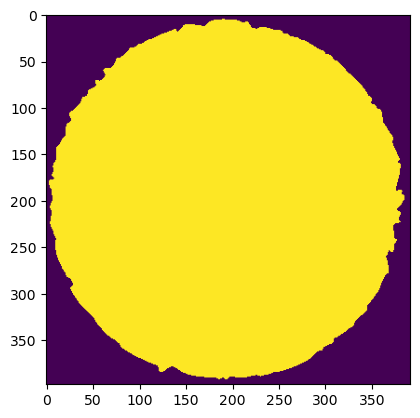

[2/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/kaurahiutale1min/capture/


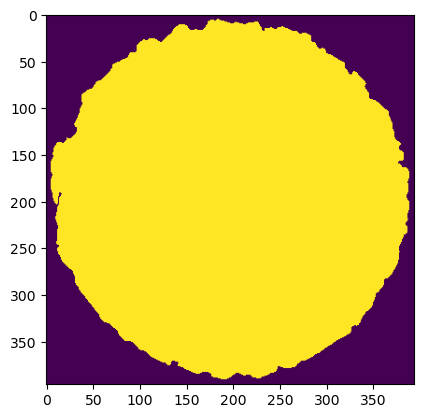

[3/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/kuivahiiva/capture/


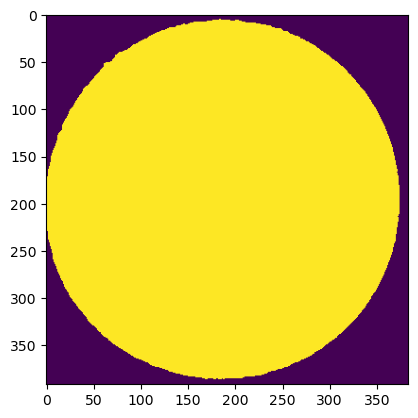

[4/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/kvinoa/capture/


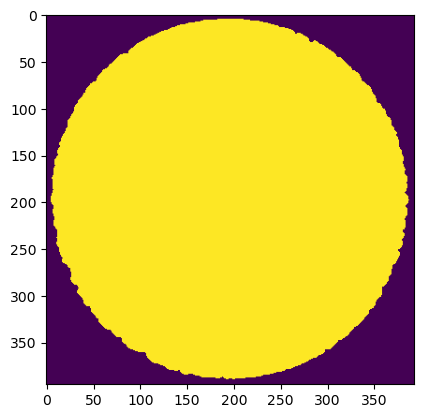

[5/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/ohrahiutale_kasittelematon/capture/


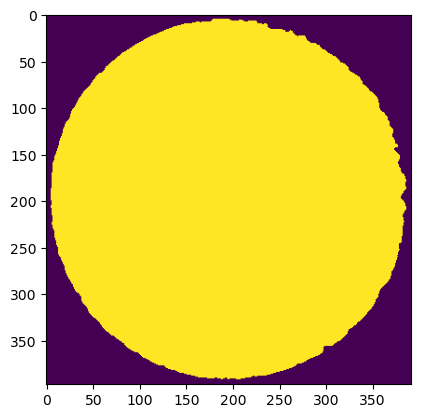

[6/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/psyllium/capture/


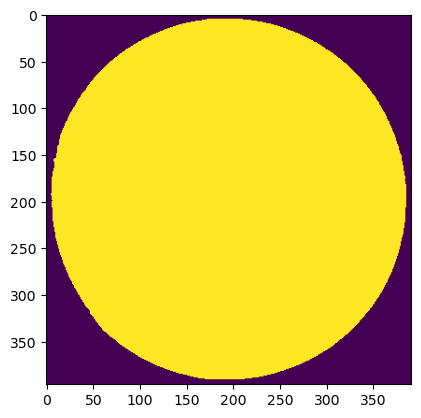

[7/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/puuroriisi/capture/


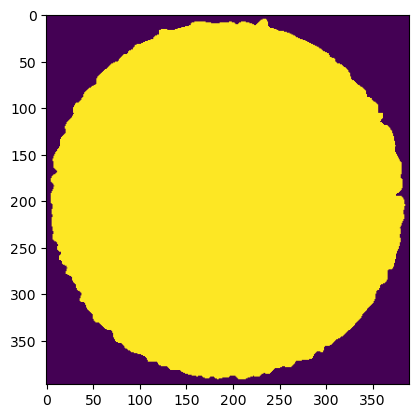

[8/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/rikottu_ohrasuurimo/capture/


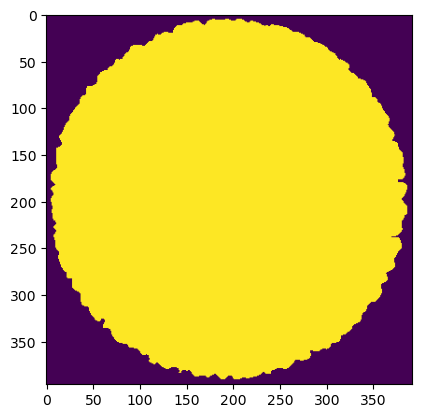

[9/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/seesaminsiemen/capture/


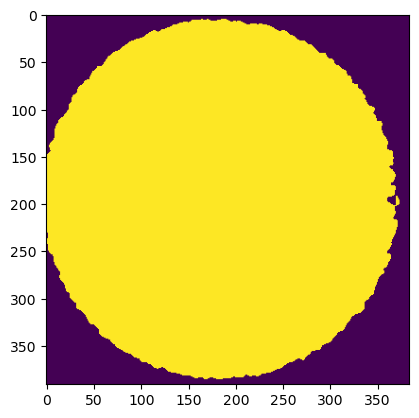

[10/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/durumvehna/capture/


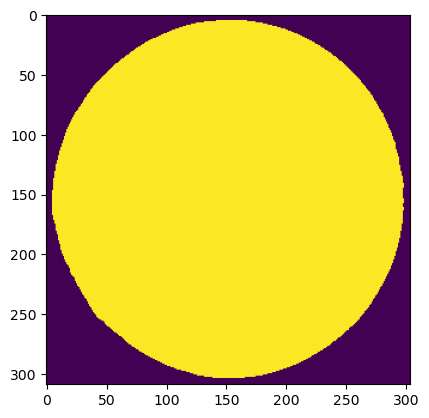

[11/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/jodioitu_suola/capture/


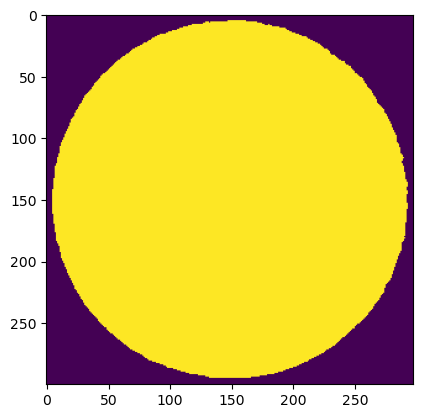

[12/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/karkea_vehnajauho/capture/


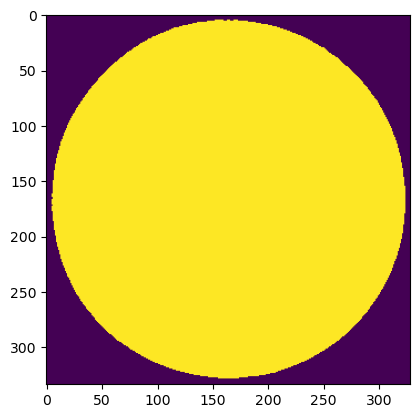

[13/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/kookoshiutale/capture/


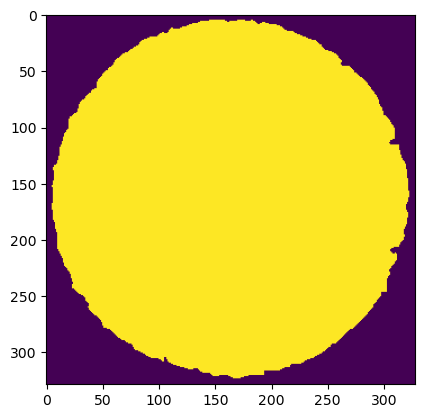

[14/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/leivinjauhe/capture/


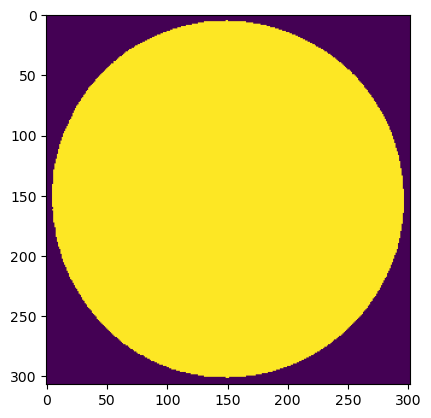

[15/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/maizena/capture/


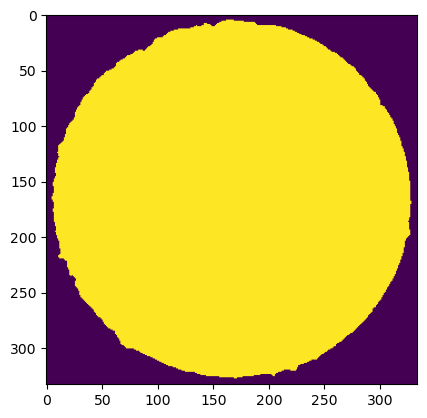

[16/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/merisuola/capture/


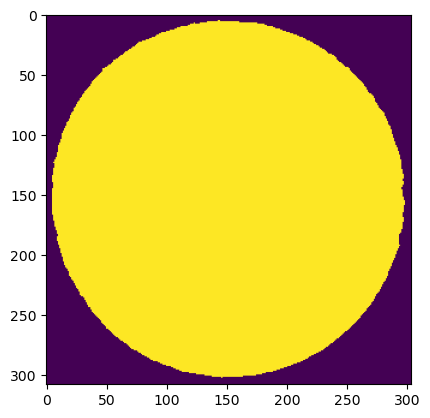

[17/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/perunajauho/capture/


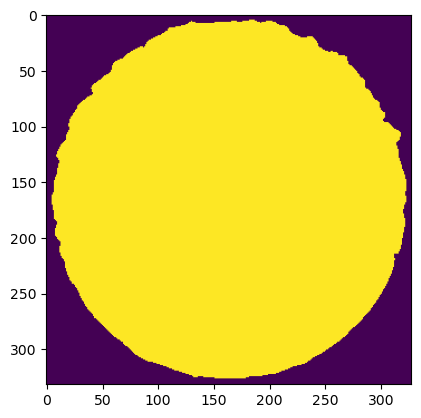

[18/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/puolikarkea_vehnajauho/capture/


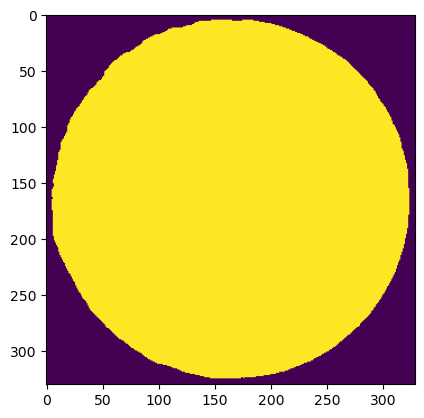

[19/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/raesokeri/capture/


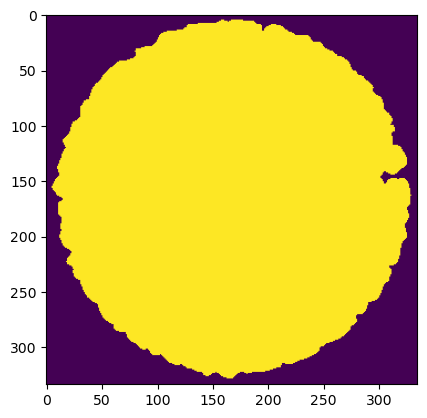

[20/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/sampylajauho/capture/


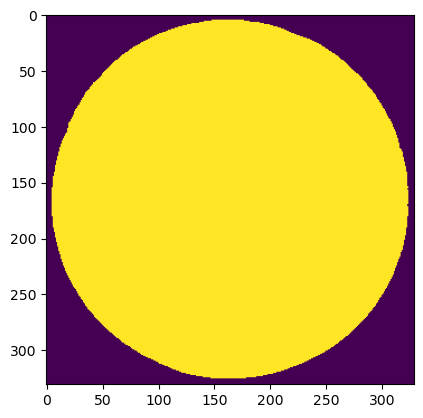

[21/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/sokeri/capture/


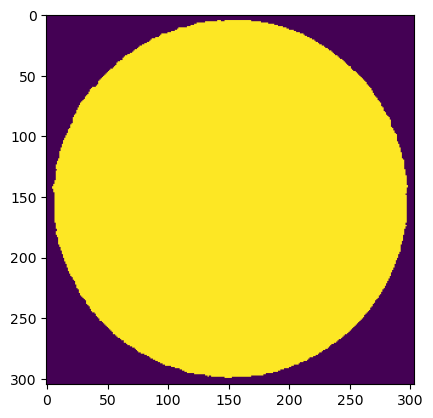

[22/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/sooda/capture/


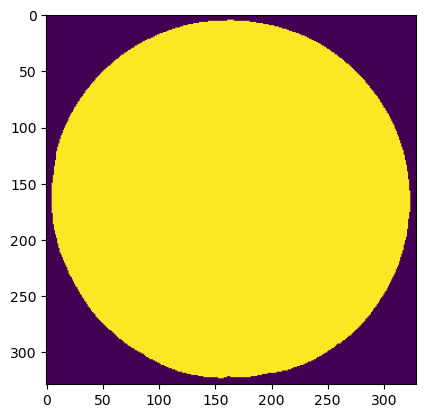

[23/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/tomusokeri/capture/


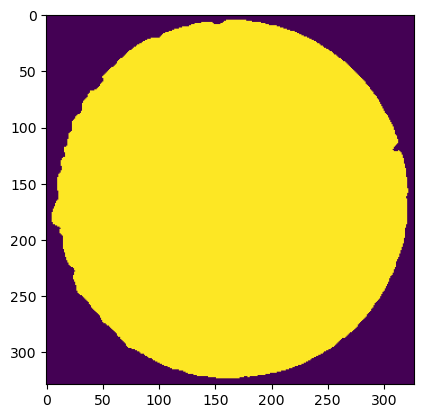


Processed 23/23 samples successfully.


In [5]:
print(f"Found {len(folders)} sample(s)\n")

spectra = []
wavelengths = None

for i, folder in enumerate(folders, 1):
    print(f"[{i}/{len(folders)}] ", end="")
    capture = os.path.join(PATH, folder, "capture/")
    print(capture)

    if not os.path.isdir(capture):
        print(f"  Skipping {folder}: no 'capture' subfolder.")
        continue

    spec, wl = process_sample(PATH, folder, nums[i-1])
    if spec is not None:
        spectra.append(spec)
        if wavelengths is None:
            wavelengths = wl


print(f"\nProcessed {len(spectra)}/{len(folders)} samples successfully.")

Now, the used wavelengths are saved in a list called `wavelengths`, the mean reflectance values of the samples in a list called `spectra` and the spectral cubes in a list called `cubes`.

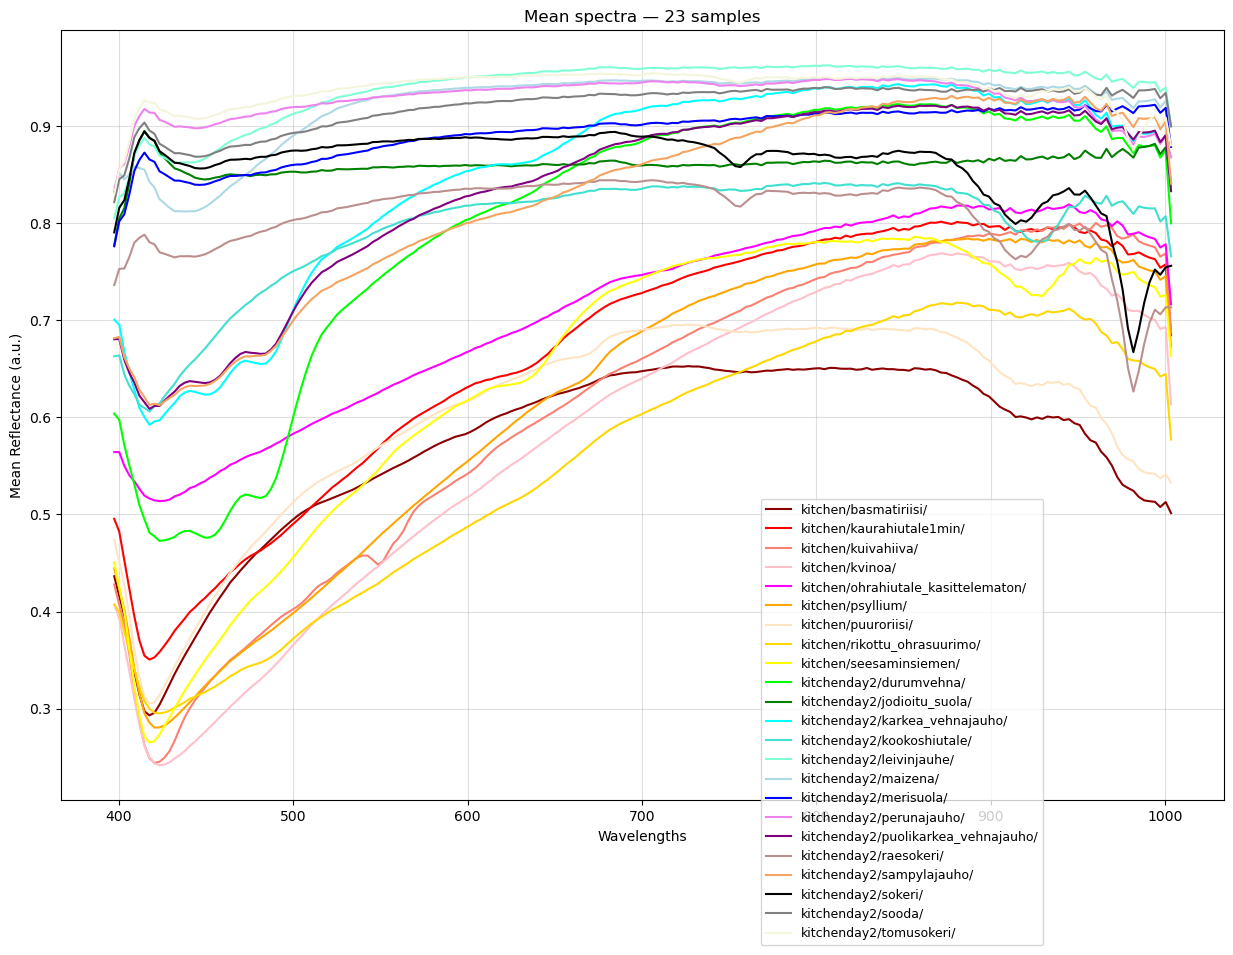

In [6]:
colors = ['darkred', 'red', 'salmon', 'pink', 'magenta', 'orange', 'bisque', 'gold', 'yellow', 'lime', 'green', 'cyan', 'turquoise', 'aquamarine', 'lightblue', 'blue', 'violet', 'purple', 'rosybrown', 'sandybrown', 'black', 'gray', 'beige']

array = np.array(spectra)
plt.figure().set_size_inches(15,10)

for i, a in enumerate(array):
    plt.plot(wavelengths, a, color=colors[i])

plt.grid(visible=True, alpha=0.4)
plt.title(f"Mean spectra — {len(spectra)} samples")
plt.xlabel('Wavelengths')
plt.ylabel('Mean Reflectance (a.u.)')
plt.legend(folders, fontsize=9, bbox_to_anchor=(0.85,0.4))
plt.show()

One way to also process spectral data is to use Multiplicative Scatter Correction (MSC). It is used to correct multiplicative deviations caused by light scattering from the sample. MSC aims to minimize the affects of these deviations by fitting a linear model between a reference spectrum and other spectra of the dataset using the linear least squares method. Usually, the reference spectrum chosen is the average of all of the spectra in the dataset. After the appliance of MSC, all of the spectra appear to have the same absorbance level.

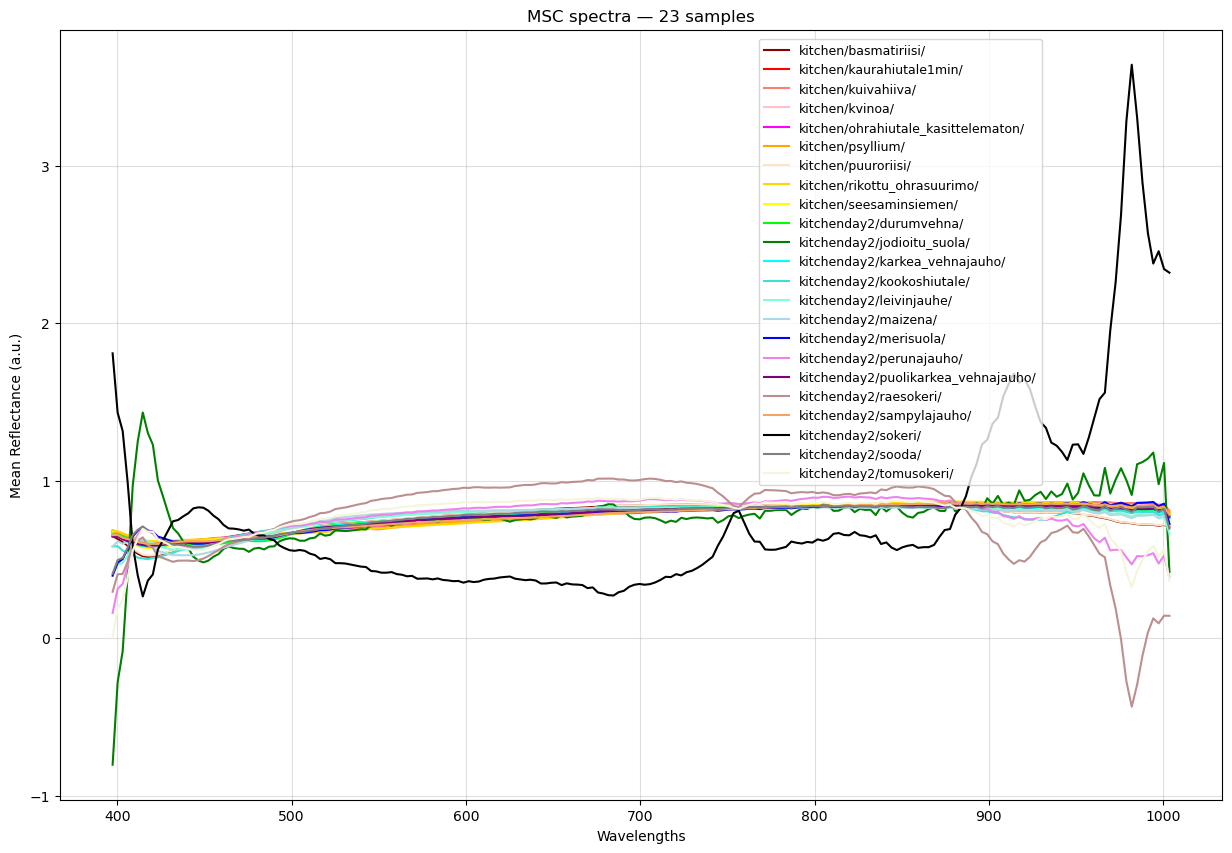

In [7]:
spectra_msc, ref_spectrum = multiplicative_scatter_correction(spectra)

plt.figure().set_size_inches(15,10)

for i, a in enumerate(spectra_msc):
    plt.plot(wavelengths, a, color=colors[i])

plt.grid(visible=True, alpha=0.4)
plt.title(f"MSC spectra — {len(spectra)} samples")
plt.xlabel('Wavelengths')
plt.ylabel('Mean Reflectance (a.u.)')
plt.legend(folders, fontsize=9, bbox_to_anchor=(0.85,0.4))
plt.show()

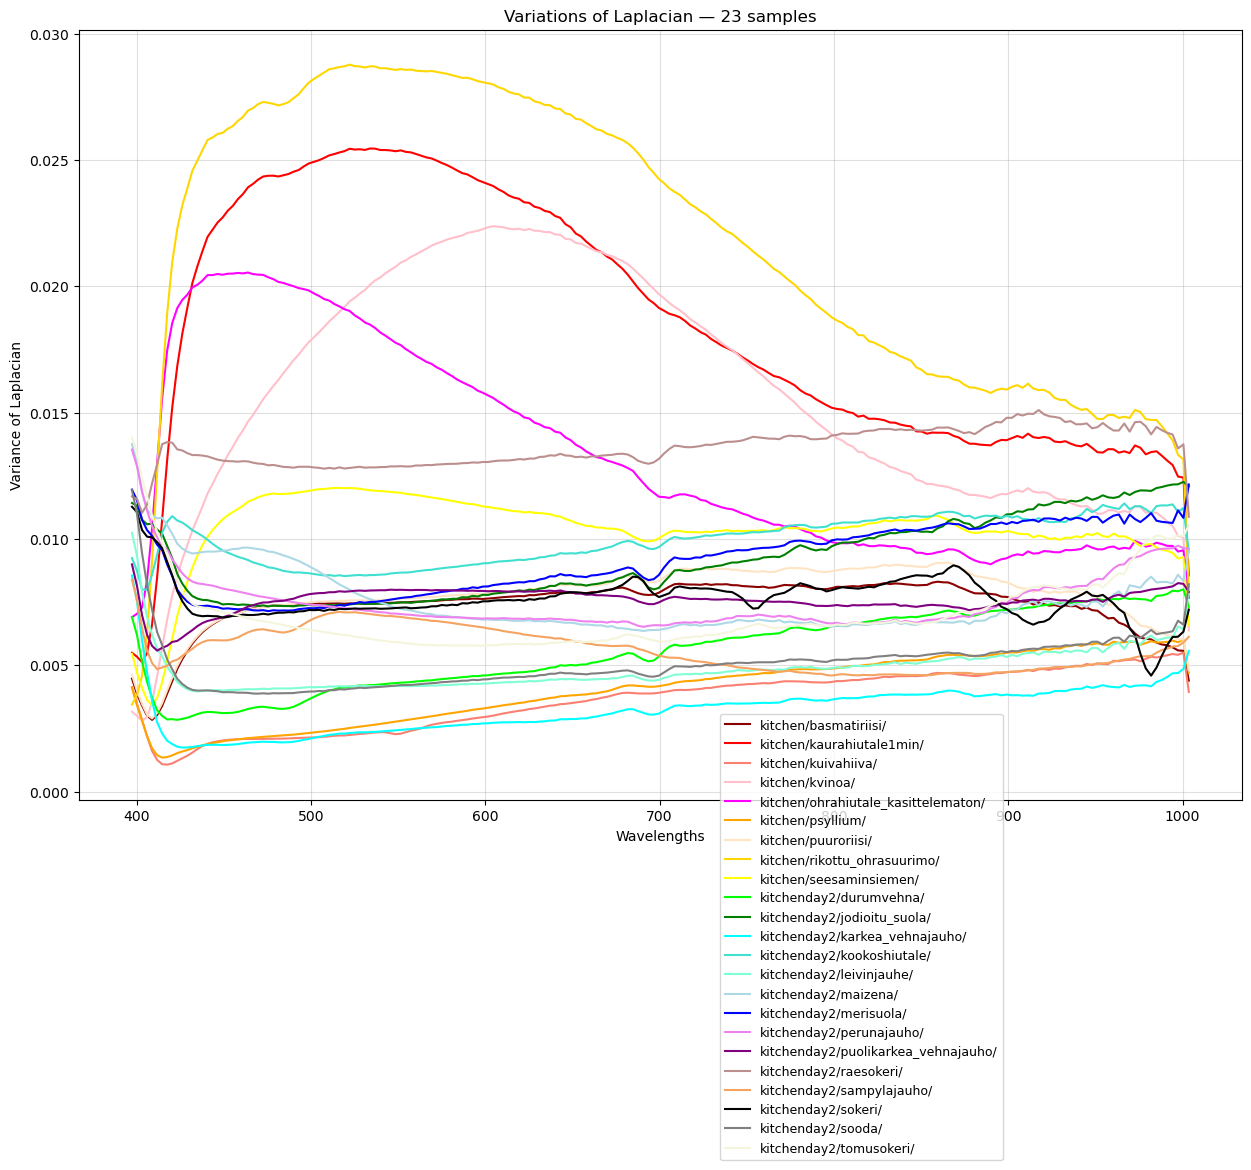

In [16]:
variances = []

for cube in cubes:
    mask = create_sample_mask(cube)
    segmented, roi_mask = segment_sample(cube, mask)

    variances.append(variance(segmented, roi_mask))


plt.figure().set_size_inches(15,10)

for i, a in enumerate(variances):
    plt.plot(wavelengths, a, color=colors[i])

plt.grid(visible=True, alpha=0.4)
plt.title(f"Variations of Laplacian — {len(spectra)} samples")
plt.xlabel('Wavelengths')
plt.ylabel('Variance of Laplacian')
plt.legend(folders, fontsize=9, bbox_to_anchor=(0.8,0.12))
plt.show()